# 8.1.1 从拟合误差到二次目标

## 学习目标与先修知识

把物质收支（mass balance）拟合写成有尺度的目标，推导值、梯度（gradient）与海森矩阵（Hessian matrix）。

先修：第3篇的向量（vector）、矩阵（matrix）和偏导（partial derivative），第6.4章的最小二乘。 [本篇学习次序](../README.md)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

一个理想清除实验中，变化率近似为 r=θ₁u−θ₂A。现在有多次输入（input）u、存量（stock）A和变化率r读数。我们不是再模拟一条轨迹（trajectory），而是选择两个系数，使预测变化率尽量接近读数。误差多小才算好，两个系数的单位又怎样进入目标？

In [1]:
import math
from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "DejaVu Sans"]
BLUE, PINK, GREEN, GRAY = "#327cac", "#c35178", "#338b7c", "#68768a"

## 初步实验

In [2]:
design = np.array([[1.,-.2],[.5,-1.],[1.5,-.6],[.8,-1.2]])
observed = np.array([.9,.05,1.2,.15])
for trial in ([0.,0.],[1.,.5],[2.,1.]):
    residual = design @ trial - observed
    print('系数', trial, '平均平方损失', float(residual @ residual/(2*len(observed))))

系数 [0.0, 0.0] 平均平方损失 0.284375
系数 [1.0, 0.5] 平均平方损失 0.000625000000000001
系数 [2.0, 1.0] 平均平方损失 0.289375


## 模型假设

原物理关系里u的单位是U/min、A是U、r是U/min；θ₁无量纲（dimensionless），θ₂为1/min。选定参考量U₀和时间T₀后，用uT₀/U₀、A/U₀、rT₀/U₀、θ₂T₀建立无量纲坐标。下面的X、y及待选系数均已按此规则换算。四行数值是固定教学例子，不是生理参数（parameter）测量；假设输入特征没有误差，先用等权残差（residual），不预先施加系数非负约束。

## 数学解释与推导

### 从逐条误差到一个目标

记第i行特征为 $a_i^T$，预测为 $a_i^Tx$。选取平方，是为了让正负误差不抵消；除以样本数，是为了比较不同大小的数据集；乘 $1/2$ 只简化导数（derivative）。

$$J(x)=\frac{1}{2n}\sum_{i=1}^n(a_i^Tx-y_i)^2
=\frac12x^THx-b^Tx+c,\quad
H=\frac{X^TX}{n},\ b=\frac{X^Ty}{n},\ c=\frac{y^Ty}{2n}.$$

常数c改变目标数值的基准，不改变哪个x最好。代码中的通用函数计算 $f=J-c$；它允许负数，不能把它叫作负的平方误差。

### 逐坐标求导，再合成向量

对x的第j分量，链式法则（chain rule）给出 $\partial J/\partial x_j=\sum_i X_{ij}(a_i^Tx-y_i)/n$。这些偏导组成梯度；再对梯度的各分量求导，得到海森矩阵：

$$\nabla J=Hx-b,\qquad \nabla^2J=H.$$

这里H对称。若有人提供非对称M，$x^TMx$ 只依赖 $(M+M^T)/2$；不能不加说明地把导数写成Mx。沿方向p的小移动满足 $J(x+tp)-J(x)=t\nabla J(x)^Tp+O(t^2)$，所以非零梯度的反方向在足够小的步长下下降。

不同单位的误差先除以相应参考尺度再相加。若改成不等权损失，权重表达对误差的相对重视，会改变问题本身。


## 核心实现

按上述推导逐步计算；保留明确的更新预算与返回标签。

In [3]:
def quadratic(matrix, linear, point):
    """f(x)=xᵀHx/2-bᵀx; inputs use the same dimensionless coordinates."""
    gradient = [sum(a*x for a, x in zip(row, point))-b
                for row, b in zip(matrix, linear)]
    value = sum(x*(g-b) for x, g, b in zip(point, gradient, linear))/2
    return value, gradient, [list(row) for row in matrix]

## 对照实验

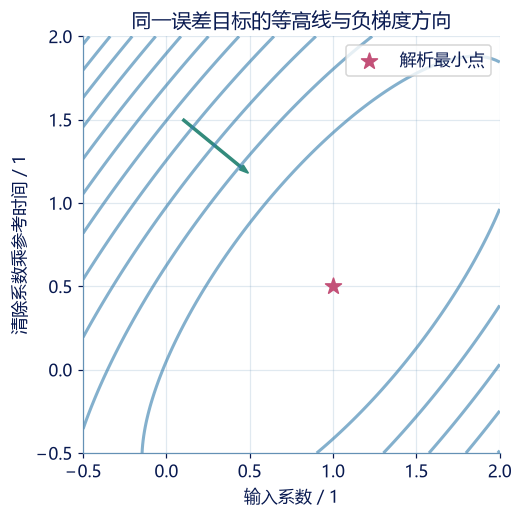

最小点 [0.99673 0.50058] 原始非负损失 0.0006181543043812243


In [4]:
H = design.T @ design / len(observed); b = design.T @ observed / len(observed)
constant = observed @ observed/(2*len(observed))
best = np.linalg.solve(H,b)
grid = np.linspace(-.5,2,100); xx,yy = np.meshgrid(grid,grid)
cost = np.array([quadratic(H,b,[x,y])[0]+constant for x,y in zip(xx.ravel(),yy.ravel())]).reshape(xx.shape)
fig,ax = plt.subplots(figsize=(6.8,4.6))
ax.contour(xx,yy,cost,levels=12,colors=BLUE,alpha=.6)
point=np.array([.1,1.5]); gradient=np.array(quadratic(H,b,point)[1])
ax.scatter(*best,color=PINK,marker='*',s=120,label='解析最小点')
ax.arrow(*point,*(-.25*gradient),width=.012,color=GREEN,length_includes_head=True)
ax.set(xlabel='输入系数 / 1',ylabel='清除系数乘参考时间 / 1',title='同一误差目标的等高线与负梯度方向')
ax.set_aspect('equal');ax.legend();plt.show()
print('最小点',best.round(5),'原始非负损失',quadratic(H,b,best)[0]+constant)

### 独立核验与边界

In [5]:
point=np.array([.7,.2]); eps=1e-5
loss=lambda x:float(np.sum((design@x-observed)**2)/(2*len(observed)))
numerical=np.array([(loss(point+eps*np.eye(2)[j])-loss(point-eps*np.eye(2)[j]))/(2*eps) for j in range(2)])
np.testing.assert_allclose(numerical,quadratic(H,b,point)[1],atol=1e-10)
np.testing.assert_allclose(H@best,b,atol=1e-12)
D=np.diag([2.,.1]); z=np.linalg.solve(D,point)
np.testing.assert_allclose(quadratic(D.T@H@D,D.T@b,z)[0],quadratic(H,b,point)[0],atol=1e-12)
print('逐坐标差分、正规方程及坐标变换检查通过。')

逐坐标差分、正规方程及坐标变换检查通过。


## 结果解释

等高线显示同一目标在不同系数组合下的数值，负梯度箭头指出局部下降方向。沿这个方向走多远，要由步长决定。解析解（analytical solution）给出当前观测（observation）损失的最小点；下一节从曲率解释这个最小点是否唯一、是否全局最优。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：计算目标与导数

将已经无量纲（dimensionless）化的收支（mass balance）误差写成二次目标。给定 H、b、x，求目标值、梯度（gradient）和海森矩阵（Hessian matrix）；不要求目标凸。

**函数与代码模板**

```python
def solve(
    matrix: list[list[float]],
    linear: list[float],
    point: list[float],
) -> tuple[float, list[float], list[list[float]]]:
    # 按题目说明计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `matrix` | `list[list[float]]` | 对称目标矩阵（matrix） H，目标为 xᵀHx/2−bᵀx。 | 无量纲 |
| `linear` | `list[float]` | 线性项 b，符号按目标中的减号。 | 无量纲 |
| `point` | `list[float]` | 当前优化变量 x。 | 无量纲 |

**返回值**

按以下顺序返回元组：(value, gradient, hessian)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `value` | `float` | 目标值 f(x)。 | 无量纲 |
| `gradient` | `list[float]` | 梯度 Hx−b。 | 无量纲 |
| `hessian` | `list[list[float]]` | 海森矩阵，等于 H。 | 无量纲 |

**计算规则**

按 f=xᵀHx/2−bᵀx 计算；不要漏掉 1/2，也不要把 b 的符号改为加号。

**约束与边界**

- 1≤维数≤3；H对称，所有元素绝对值≤20。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| matrix | 对称目标矩阵（matrix） H，目标为 xᵀHx/2−bᵀx。 | [[2.0, 1.0], [1.0, 4.0]] | 无量纲 |
| linear | 线性项 b，符号按目标中的减号。 | [1.0, 2.0] | 无量纲 |
| point | 当前优化变量 x。 | [2.0, -1.0] | 无量纲 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
matrix = [[2.0, 1.0], [1.0, 4.0]]
linear = [1.0, 2.0]
point = [2.0, -1.0]

result = solve(matrix, linear, point)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| value | 目标值 f(x)。 | 4 | 无量纲 |
| gradient | 梯度 Hx−b。 | [2.0, -4.0] | 无量纲 |
| hessian | 海森矩阵，等于 H。 | [[2.0, 1.0], [1.0, 4.0]] | 无量纲 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (4.0,
                   [2.0, -4.0],
                   [[2.0, 1.0], [1.0, 4.0]])
```

**样例解释**

先算 Hx=[3,−2]，梯度=[2,−4]；目标值为4。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：计算目标与导数](http://127.0.0.1:8000/chapters/08-01-%E7%9B%AE%E6%A0%87%E5%87%BD%E6%95%B0%E4%B8%8E%E4%BC%98%E5%8C%96%E5%87%A0%E4%BD%95/practice/?question=p08-quadratic)

### 第 2 题 · 多项选择题：相加之前先比较单位

两个观测（observation）残差（residual）分别以U和U/min表示。怎样构造可解释的无量纲（dimensionless）拟合目标？

- **A.** 分别除以预先给定的同单位参考尺度，再平方求和。
- **B.** 直接相加平方，因为平方会自动消除单位。
- **C.** 改变某项无量纲权重一般会改变所偏好的解。
- **D.** 把所有项同时乘同一正常数，最小点集合不变。

[作答：相加之前先比较单位](http://127.0.0.1:8000/chapters/08-01-%E7%9B%AE%E6%A0%87%E5%87%BD%E6%95%B0%E4%B8%8E%E4%BC%98%E5%8C%96%E5%87%A0%E4%BD%95/practice/?question=p08-loss-units)

### 第 3 题 · 单项选择题：梯度指向哪里

光滑目标在 x 的梯度（gradient） g 非零。对很小的正数 t，沿哪个方向保证一阶变化为负？

- **A.** 任意方向。
- **B.** −g。
- **C.** g。
- **D.** 与g垂直的方向必下降。

[作答：梯度指向哪里](http://127.0.0.1:8000/chapters/08-01-%E7%9B%AE%E6%A0%87%E5%87%BD%E6%95%B0%E4%B8%8E%E4%BC%98%E5%8C%96%E5%87%A0%E4%BD%95/practice/?question=p08-gradient-direction)

### 第 4 题 · 多项选择题：单位改变还是问题改变

令原变量 x=Dz，D为正的对角矩阵（matrix）。以下哪些转换保持同一个目标问题？

- **A.** 只替换变量名称，保留原H、b。
- **B.** H改为DᵀHD，b改为Dᵀb。
- **C.** 约束与初值（initial condition）也应按x=Dz转换。
- **D.** 可以随意改变其中一个残差（residual）权重而称为单位转换。

[作答：单位改变还是问题改变](http://127.0.0.1:8000/chapters/08-01-%E7%9B%AE%E6%A0%87%E5%87%BD%E6%95%B0%E4%B8%8E%E4%BC%98%E5%8C%96%E5%87%A0%E4%BD%95/practice/?question=p08-change-coordinates)

### 延伸阅读

[Boyd 与 Vandenberghe：《Convex Optimization》](https://web.stanford.edu/~boyd/cvxbook/)，第3章的二次函数与第4章的优化问题表达。

[概念探索与交互](http://127.0.0.1:8000/chapters/08-01-目标函数与优化几何/explore/) · [本篇目录](../README.md)